<a href="https://colab.research.google.com/github/Lekanggy/MLrepo/blob/main/Varying_dropout_layers_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, random_split
import torchvision
import torchvision.transforms as transforms

In [ ]:
# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Global config
CONFIG = {
    "subset_fraction": 0.30,   # use 20% of CIFAR-10
    "val_fraction": 0.20,      # 20% of subset for validation
    "batch_size": 128,
    "epochs": 15,
    "lr": 1e-3,
    "num_workers": 2,
}

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

Using device: cuda


#**Build Exploratory Data Pipline**

In [ ]:
class EDAPipeline:
    """Performs exploratory data analysis on CIFAR-10."""

    def __init__(self):
        self.train_data = None
        self.test_data = None
        self.mean = None
        self.std = None

    def load_raw(self):
        """Load raw CIFAR-10 (no transforms, just ToTensor)."""
        base_tf = transforms.ToTensor()
        self.train_data = torchvision.datasets.CIFAR10(
            root="./data", train=True, download=True, transform=base_tf)
        self.test_data = torchvision.datasets.CIFAR10(
            root="./data", train=False, download=True, transform=base_tf)
        print(f"Train size: {len(self.train_data)}")
        print(f"Test size : {len(self.test_data)}")
        return self

    def basic_info(self):
        img, lbl = self.train_data[0]
        print("\n=== BASIC INFO ===")
        print(f"Image dtype        : {img.dtype}")
        print(f"Image shape        : {img.shape}  (C, H, W)")
        print(f"Number of classes  : {len(CLASS_NAMES)}")
        print(f"Classes            : {CLASS_NAMES}")
        print(f"Train images       : {len(self.train_data)}")
        print(f"Test images        : {len(self.test_data)}")

        # Missing values check (CIFAR is clean by design)
        arr = self.train_data.data  # (N, 32, 32, 3) uint8
        print(f"Train array shape  : {arr.shape}")
        print(f"NaN count          : {np.isnan(arr).sum()}")
        print(f"Min pixel / Max    : {arr.min()} / {arr.max()}")
        print(f"Dtype              : {arr.dtype}")
        return self

    def plot_class_distribution(self):
        train_labels = np.array(self.train_data.targets)
        test_labels = np.array(self.test_data.targets)

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        sns.countplot(x=train_labels, ax=axes[0], palette="viridis")
        axes[0].set_xticks(range(10))
        axes[0].set_xticklabels(CLASS_NAMES, rotation=45)
        axes[0].set_title("CIFAR-10 Training Set Class Distribution")
        axes[0].set_xlabel("Class")
        axes[0].set_ylabel("Count")

        sns.countplot(x=test_labels, ax=axes[1], palette="magma")
        axes[1].set_xticks(range(10))
        axes[1].set_xticklabels(CLASS_NAMES, rotation=45)
        axes[1].set_title("CIFAR-10 Test Set Class Distribution")
        axes[1].set_xlabel("Class")
        axes[1].set_ylabel("Count")
        plt.tight_layout()
        plt.show()

        # Print percentages
        counts = Counter(train_labels)
        print("\nClass distribution (train):")
        for k in sorted(counts):
            print(f"  {CLASS_NAMES[k]:12s}: {counts[k]} "
                  f"({100*counts[k]/len(train_labels):.1f}%)")
        return self

    def plot_sample_images(self, n_per_class=5):
        fig, axes = plt.subplots(10, n_per_class, figsize=(n_per_class*2, 14))
        for cls in range(10):
            idxs = np.where(np.array(self.train_data.targets) == cls)[0][:n_per_class]
            for j, idx in enumerate(idxs):
                axes[cls, j].imshow(self.train_data.data[idx])
                axes[cls, j].axis("off")
                if j == 0:
                    axes[cls, j].set_ylabel(CLASS_NAMES[cls], fontsize=10)
        plt.suptitle("Sample Images per Class", fontsize=14)
        plt.tight_layout()
        plt.show()
        return self

    def plot_pixel_distribution(self):
        arr = self.train_data.data.astype(np.float32) / 255.0
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        colors = ['Red', 'Green', 'Blue']
        for ch in range(3):
            sns.histplot(arr[..., ch].ravel(), bins=50, ax=axes[ch],
                         color=colors[ch].lower(), alpha=0.7)
            axes[ch].set_title(f"{colors[ch]} Channel Pixel Distribution")
            axes[ch].set_xlabel("Pixel intensity (0-1)")
        plt.tight_layout()
        plt.show()
        return self

    def compute_normalization_stats(self):
        arr = self.train_data.data.astype(np.float32) / 255.0
        self.mean = arr.mean(axis=(0,1,2))
        self.std  = arr.std(axis=(0,1,2))
        print(f"\nNormalization mean (R,G,B): {self.mean}")
        print(f"Normalization std  (R,G,B): {self.std}")
        return self

    def summary(self):
        print("\n=== EDA SUMMARY ===")
        print("• CIFAR-10 contains 60,000 32x32 RGB images across 10 classes.")
        print("• Classes are perfectly balanced (6,000 per class in train, 1,000 in test).")
        print("• No missing values, no corrupt images — dataset is clean.")
        print("• Pixel intensities span 0-255; channels have similar distributions.")
        print("• Normalization stats computed for use in transforms.")
        return self

100%|██████████| 170M/170M [56:20<00:00, 50.4kB/s]


Train size: 50000
Test size : 10000

=== BASIC INFO ===
Image dtype        : torch.float32
Image shape        : torch.Size([3, 32, 32])  (C, H, W)
Number of classes  : 10
Classes            : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train images       : 50000
Test images        : 10000
Train array shape  : (50000, 32, 32, 3)
NaN count          : 0
Min pixel / Max    : 0 / 255
Dtype              : uint8


/tmp/ipykernel_2460/225414754.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_labels, ax=axes[0], palette="viridis")
/tmp/ipykernel_2460/225414754.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=test_labels, ax=axes[1], palette="magma")


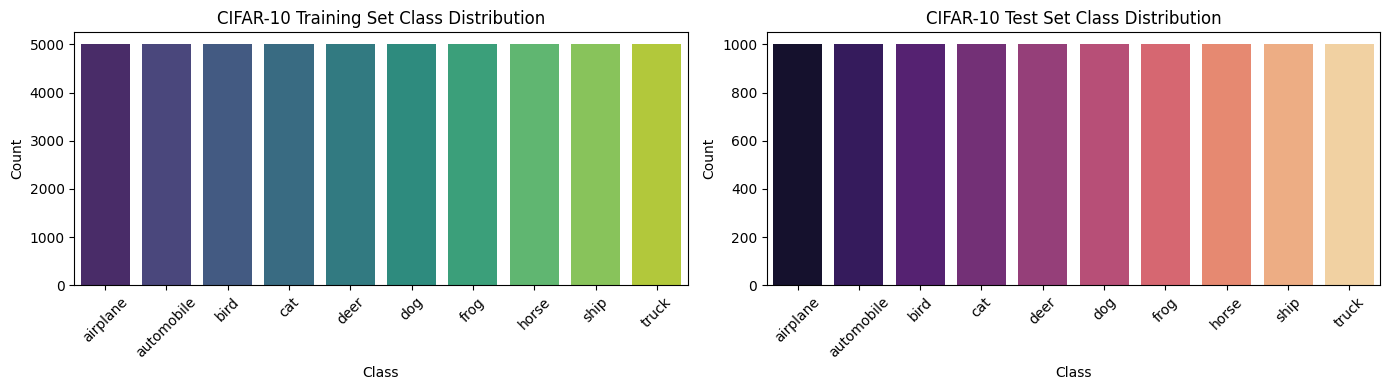


Class distribution (train):
  airplane    : 5000 (10.0%)
  automobile  : 5000 (10.0%)
  bird        : 5000 (10.0%)
  cat         : 5000 (10.0%)
  deer        : 5000 (10.0%)
  dog         : 5000 (10.0%)
  frog        : 5000 (10.0%)
  horse       : 5000 (10.0%)
  ship        : 5000 (10.0%)
  truck       : 5000 (10.0%)


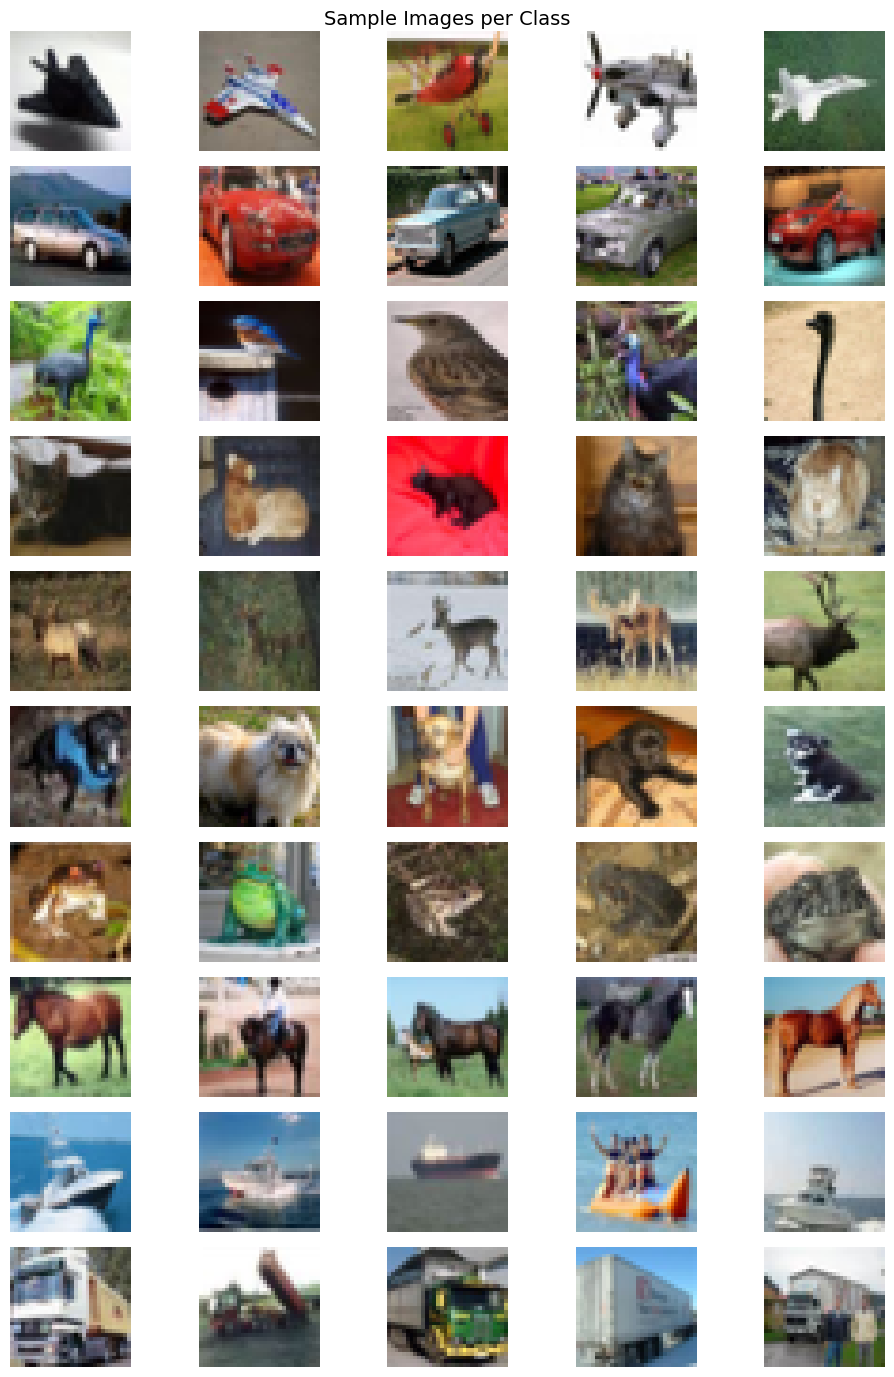

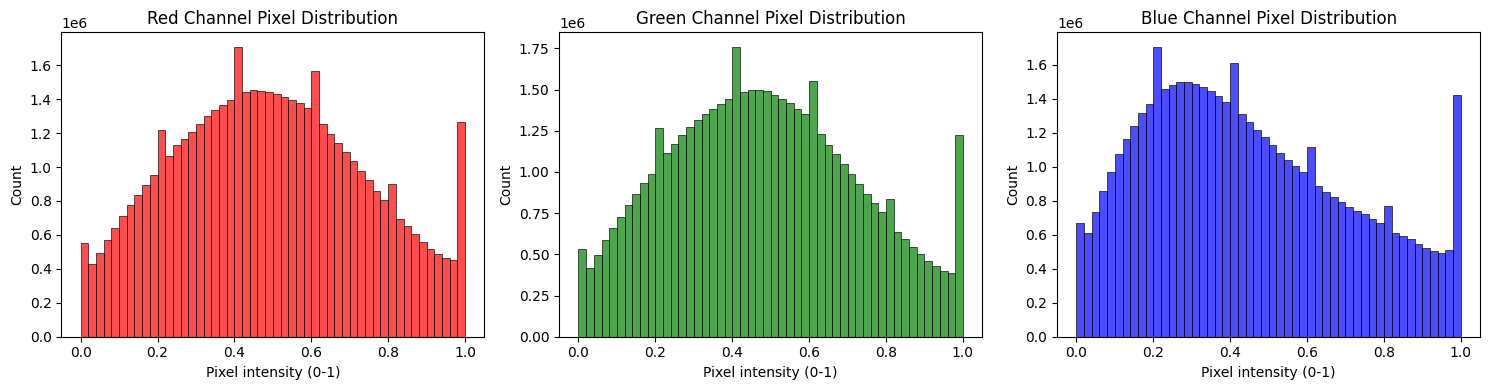


Normalization mean (R,G,B): [0.4914009  0.48215896 0.4465308 ]
Normalization std  (R,G,B): [0.24703279 0.24348423 0.26158753]

=== EDA SUMMARY ===
• CIFAR-10 contains 60,000 32x32 RGB images across 10 classes.
• Classes are perfectly balanced (6,000 per class in train, 1,000 in test).
• No missing values, no corrupt images — dataset is clean.
• Pixel intensities span 0-255; channels have similar distributions.
• Normalization stats computed for use in transforms.


In [ ]:
eda = EDAPipeline()
eda.load_raw()\
   .basic_info()\
   .plot_class_distribution()\
   .plot_sample_images()\
   .plot_pixel_distribution()\
   .compute_normalization_stats()\
   .summary()

#**Data Module for Loading the Data**

In [ ]:
class DataModule:
    """Builds balanced subset + train/val DataLoaders."""

    def __init__(self, mean, std, config=CONFIG):
        self.mean = mean
        self.std = std
        self.config = config
        self.train_loader = None
        self.val_loader = None

    def _build_transform(self):
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(self.mean, self.std),
        ])

    def _balanced_subset(self, dataset, fraction, seed=SEED):
        """Stratified subsample preserving class balance."""
        targets = np.array(dataset.targets)
        rng = np.random.default_rng(seed)
        chosen_idx = []
        for cls in np.unique(targets):
            cls_idx = np.where(targets == cls)[0]
            n_keep = max(1, int(len(cls_idx) * fraction))
            chosen_idx.extend(rng.choice(cls_idx, size=n_keep, replace=False))
        rng.shuffle(chosen_idx)
        return Subset(dataset, chosen_idx)

    def prepare(self):
        tf = self._build_transform()
        full_train = torchvision.datasets.CIFAR10(
            root="./data", train=True, download=False, transform=tf)

        subset = self._balanced_subset(full_train, self.config["subset_fraction"])
        n_val = int(len(subset) * self.config["val_fraction"])
        n_train = len(subset) - n_val

        train_subset, val_subset = random_split(
            subset, [n_train, n_val],
            generator=torch.Generator().manual_seed(SEED))

        self.train_loader = DataLoader(train_subset,
                                       batch_size=self.config["batch_size"],
                                       shuffle=True,
                                       num_workers=self.config["num_workers"])
        self.val_loader = DataLoader(val_subset,
                                     batch_size=self.config["batch_size"],
                                     shuffle=False,
                                     num_workers=self.config["num_workers"])

        print(f"Subset size      : {len(subset)} "
              f"({self.config['subset_fraction']*100:.0f}% of CIFAR-10)")
        print(f"Train batches    : {len(self.train_loader)}")
        print(f"Val   batches    : {len(self.val_loader)}")
        return self

#**Model Module**

In [ ]:
class ConfigurableCNN(nn.Module):
    """
    CNN whose depth and dropout are configurable at construction time.
    - num_conv_layers: number of Conv blocks (Conv -> BN -> ReLU -> Pool)
    - dropout_rate   : dropout applied after each conv block and in the head
    """

    def __init__(self, num_conv_layers=3, dropout_rate=0.25,
                 num_classes=10, base_channels=32):
        super().__init__()
        assert 1 <= num_conv_layers <= 5, "num_conv_layers must be 1..5"
        assert 0.0 <= dropout_rate < 1.0

        self.num_conv_layers = num_conv_layers
        self.dropout_rate = dropout_rate

        layers = []
        in_ch = 3
        for i in range(num_conv_layers):
            out_ch = base_channels * (2 ** i)   # 32, 64, 128, 256, 512
            layers.append(nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1))
            layers.append(nn.BatchNorm2d(out_ch))
            layers.append(nn.ReLU(inplace=True))
            layers.append(nn.MaxPool2d(2, 2))                # halve H,W
            if dropout_rate > 0:
                layers.append(nn.Dropout2d(dropout_rate))
            in_ch = out_ch
        self.conv = nn.Sequential(*layers)

        # After k pools: H = 32 / 2^k
        final_spatial = 32 // (2 ** num_conv_layers)
        if final_spatial < 1:
            raise ValueError("Too many conv layers for 32x32 input.")
        flat_dim = in_ch * final_spatial * final_spatial

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.head(x)
        return x

    def __repr__(self):
        return (f"ConfigurableCNN(conv_layers={self.num_conv_layers}, "
                f"dropout={self.dropout_rate})")


def build_model(num_conv_layers, dropout_rate):
    """Factory used by the experiment runner."""
    model = ConfigurableCNN(num_conv_layers=num_conv_layers,
                            dropout_rate=dropout_rate).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Built {model}  |  trainable params: {n_params:,}")
    return model

In [ ]:

#Sanity check on the module
dummy = torch.randn(2, 3, 32, 32).to(DEVICE)
m = build_model(num_conv_layers=3, dropout_rate=0.25)
print("Output shape:", m(dummy).shape)   # (2, 10)

Built ConfigurableCNN(conv_layers=3, dropout=0.25)  |  trainable params: 357,258
Output shape: torch.Size([2, 10])


In [ ]:
del m

#**Traning Module**

In [ ]:
class Trainer:
    """Handles training & validation loops for a given model."""

    def __init__(self, model, train_loader, val_loader,
                 lr=CONFIG["lr"], epochs=CONFIG["epochs"]):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.epochs = epochs
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        self.history = {"train_loss": [], "train_acc": [],
                        "val_loss": [], "val_acc": []}

    def _run_epoch(self, loader, train=True):
        self.model.train() if train else self.model.eval()
        total_loss, correct, total = 0.0, 0, 0
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for X, y in loader:
                X, y = X.to(DEVICE), y.to(DEVICE)
                out = self.model(X)
                loss = self.criterion(out, y)
                if train:
                    self.optimizer.zero_grad()
                    loss.backward()
                    self.optimizer.step()
                total_loss += loss.item() * X.size(0)
                correct += (out.argmax(1) == y).sum().item()
                total += X.size(0)
        return total_loss / total, correct / total

    def train(self, verbose=True):
        for ep in range(self.epochs):
            tr_loss, tr_acc = self._run_epoch(self.train_loader, train=True)
            vl_loss, vl_acc = self._run_epoch(self.val_loader, train=False)
            self.history["train_loss"].append(tr_loss)
            self.history["train_acc"].append(tr_acc)
            self.history["val_loss"].append(vl_loss)
            self.history["val_acc"].append(vl_acc)
            if verbose:
                print(f"  Epoch {ep+1:02d}/{self.epochs} | "
                      f"train_loss={tr_loss:.4f} train_acc={tr_acc:.3f} | "
                      f"val_loss={vl_loss:.4f} val_acc={vl_acc:.3f}")
        return self.history

    @property
    def best_val_acc(self):
        return max(self.history["val_acc"])

#**Experimentation Module**

In [ ]:
def run_experiments(data_module):
    """
    Run two ablation studies:
      A) Vary # conv layers (fixed dropout = 0.25)
      B) Vary dropout rate  (fixed # conv layers = 3)
    """
    results = {"conv_layers": {}, "dropout": {}}

    # ----- A) Vary # conv layers -----
    print("\n\n### EXPERIMENT A: Vary # convolutional layers (dropout=0.25) ###")
    for n_conv in [2, 3, 4]:
        print(f"\n--- Training with {n_conv} conv layers ---")
        model = build_model(num_conv_layers=n_conv, dropout_rate=0.25)
        trainer = Trainer(model, data_module.train_loader, data_module.val_loader)
        trainer.train()
        results["conv_layers"][n_conv] = trainer.history
        del model, trainer
        torch.cuda.empty_cache() if DEVICE.type == "cuda" else None

    # ----- B) Vary dropout rate -----
    print("\n\n### EXPERIMENT B: Vary dropout rate (conv_layers=3) ###")
    for dr in [0.0, 0.25, 0.5]:
        print(f"\n--- Training with dropout = {dr} ---")
        model = build_model(num_conv_layers=3, dropout_rate=dr)
        trainer = Trainer(model, data_module.train_loader, data_module.val_loader)
        trainer.train()
        results["dropout"][dr] = trainer.history
        del model, trainer
        torch.cuda.empty_cache() if DEVICE.type == "cuda" else None

    return results

#**Visualisation Helper**

In [ ]:
def plot_experiment_results(results):
    # ---- Conv layers experiment ----
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for n_conv, hist in results["conv_layers"].items():
        axes[0].plot(hist["val_acc"], label=f"{n_conv} conv layers", marker="o")
    axes[0].set_title("Validation Accuracy vs Epochs\n(Varying # Conv Layers, dropout=0.25)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Val Accuracy")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Bar chart of best val accuracy per #conv
    best = {k: max(v["val_acc"]) for k, v in results["conv_layers"].items()}
    axes[1].bar([str(k) for k in best.keys()], best.values(),
                color=["#4C72B0", "#55A868", "#C44E52"])
    axes[1].set_title("Best Val Accuracy by # Conv Layers")
    axes[1].set_xlabel("Number of Conv Layers")
    axes[1].set_ylabel("Best Val Accuracy")
    for i, (k, v) in enumerate(best.items()):
        axes[1].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)
    plt.tight_layout()
    plt.show()

    # ---- Dropout experiment ----
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for dr, hist in results["dropout"].items():
        axes[0].plot(hist["val_acc"], label=f"dropout={dr}", marker="s")
    axes[0].set_title("Validation Accuracy vs Epochs\n(Varying Dropout, 3 conv layers)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Val Accuracy")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    best = {k: max(v["val_acc"]) for k, v in results["dropout"].items()}
    axes[1].bar([str(k) for k in best.keys()], best.values(),
                color=["#8172B2", "#CCB974", "#64B5CD"])
    axes[1].set_title("Best Val Accuracy by Dropout Rate")
    axes[1].set_xlabel("Dropout Rate")
    axes[1].set_ylabel("Best Val Accuracy")
    for i, (k, v) in enumerate(best.items()):
        axes[1].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)
    plt.tight_layout()
    plt.show()


def print_report(results):
    print("\n" + "="*60)
    print("FINAL REPORT — Impact of Conv Layers & Dropout on Val Acc")
    print("="*60)
    print("\nExperiment A — # Convolutional Layers (dropout fixed = 0.25):")
    for n, h in results["conv_layers"].items():
        print(f"  {n} conv layers  -> best val acc = {max(h['val_acc']):.4f}")
    print("\nExperiment B — Dropout Rate (# conv layers fixed = 3):")
    for d, h in results["dropout"].items():
        print(f"  dropout = {d:.2f}  -> best val acc = {max(h['val_acc']):.4f}")
    print("="*60)

#**Main Driver for the experiment**

Subset size      : 15000 (30% of CIFAR-10)
Train batches    : 94
Val   batches    : 24


### EXPERIMENT A: Vary # convolutional layers (dropout=0.25) ###

--- Training with 2 conv layers ---
Built ConfigurableCNN(conv_layers=2, dropout=0.25)  |  trainable params: 545,290
  Epoch 01/15 | train_loss=1.8783 train_acc=0.324 | val_loss=1.6064 val_acc=0.426
  Epoch 02/15 | train_loss=1.6227 train_acc=0.414 | val_loss=1.4275 val_acc=0.499
  Epoch 03/15 | train_loss=1.5097 train_acc=0.458 | val_loss=1.3691 val_acc=0.512
  Epoch 04/15 | train_loss=1.4342 train_acc=0.488 | val_loss=1.3155 val_acc=0.530
  Epoch 05/15 | train_loss=1.3562 train_acc=0.510 | val_loss=1.2400 val_acc=0.554
  Epoch 06/15 | train_loss=1.2989 train_acc=0.532 | val_loss=1.2049 val_acc=0.565
  Epoch 07/15 | train_loss=1.2565 train_acc=0.550 | val_loss=1.1862 val_acc=0.567
  Epoch 08/15 | train_loss=1.2222 train_acc=0.562 | val_loss=1.1616 val_acc=0.583
  Epoch 09/15 | train_loss=1.1777 train_acc=0.577 | val_loss=1.1253 val_

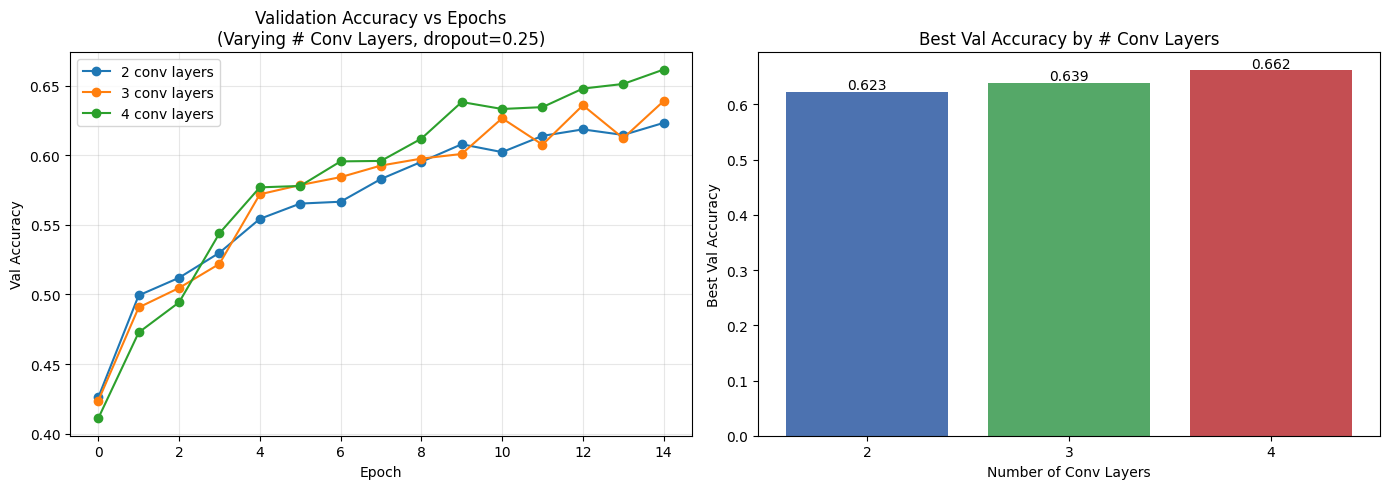

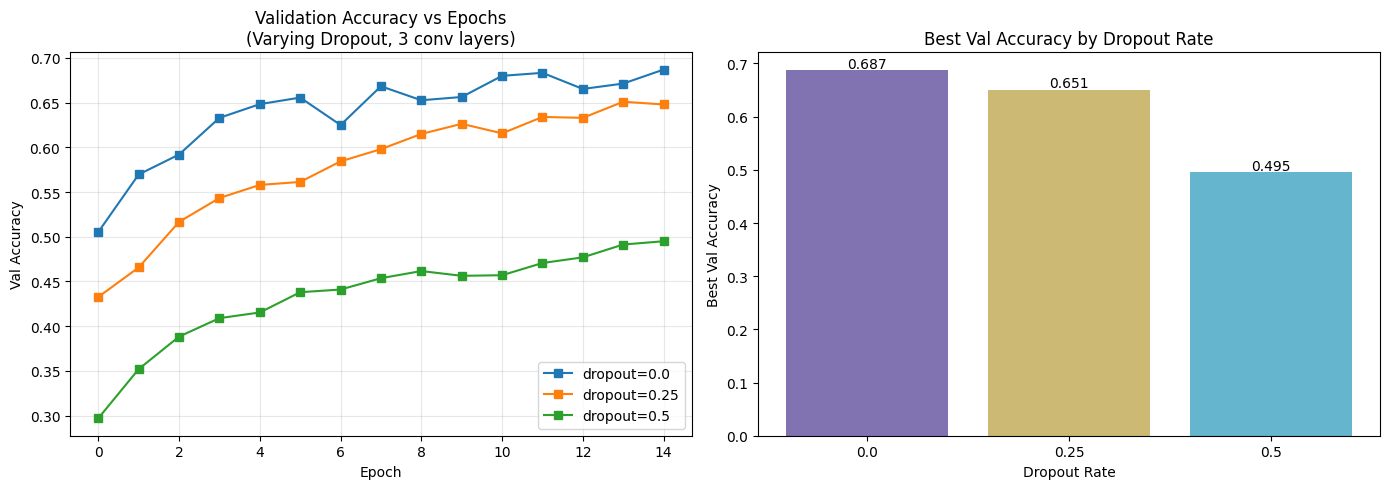


FINAL REPORT — Impact of Conv Layers & Dropout on Val Acc

Experiment A — # Convolutional Layers (dropout fixed = 0.25):
  2 conv layers  -> best val acc = 0.6233
  3 conv layers  -> best val acc = 0.6390
  4 conv layers  -> best val acc = 0.6617

Experiment B — Dropout Rate (# conv layers fixed = 3):
  dropout = 0.00  -> best val acc = 0.6870
  dropout = 0.25  -> best val acc = 0.6510
  dropout = 0.50  -> best val acc = 0.4950


In [ ]:
if __name__ == "__main__":
    # 1) EDA already executed above (eda object populated)

    # 2) Build data module with normalization stats from EDA
    dm = DataModule(mean=eda.mean, std=eda.std, config=CONFIG).prepare()

    # 3) Model is already built/tested in section 4

    # 4) Run the two ablation experiments
    results = run_experiments(dm)

    # 5) Visualize & report
    plot_experiment_results(results)
    print_report(results)